In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch
from Ridge import RidgeRegression
import matplotlib.pyplot as plt

In [16]:
def generate_ridge_data(
    n=100,          # sample number
    d=10,           # feature dim
    noise_std=0.1,  # noise
    collinear=True, 
    seed=0
):
    torch.manual_seed(seed)
    
    X = torch.randn(n, d)
  
    if collinear and d >= 2:
        for i in range(1, d):
            X[:, i] = X[:, 0] + 0.01 * torch.randn(n)

    w_true = torch.randn(d, 1)
    b_true = torch.randn(1)
   
    y = X @ w_true + b_true
    y += noise_std * torch.randn(n, 1)
    
    return X, y, w_true, b_true

X, y, w_true, b_true = generate_ridge_data()

# Ridge Regression

In [17]:
ridge=RidgeRegression(lam=1)
ridge.closed_form_solution(X,y)

print(ridge.w_hat)

print(w_true,b_true)

tensor([[-0.1478],
        [-0.1542],
        [-0.1519],
        [-0.1492],
        [-0.1516],
        [-0.1281],
        [-0.1373],
        [-0.1415],
        [-0.1478],
        [-0.1549],
        [-1.3671]])
tensor([[-1.0583],
        [-0.3045],
        [ 0.6026],
        [ 0.0248],
        [-0.6334],
        [ 1.6359],
        [ 0.9025],
        [-0.1421],
        [-0.6309],
        [-1.8677]]) tensor([-1.3800])


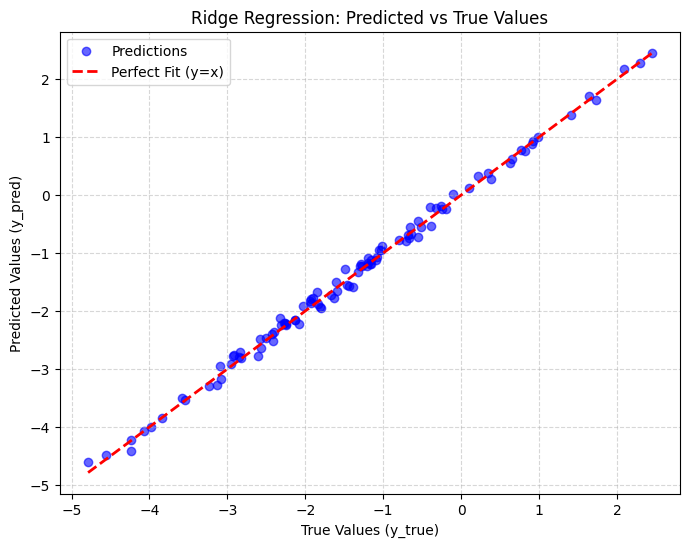

In [18]:
w_calc = ridge.w_hat[:-1]
b_calc = ridge.w_hat[-1]
y_pred = X @ w_calc + b_calc

plt.figure(figsize=(8, 6))
plt.scatter(y.numpy(), y_pred.detach().numpy(), alpha=0.6, color='blue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit (y=x)')

plt.xlabel('True Values (y_true)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Ridge Regression: Predicted vs True Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()